In [3]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

In [4]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [5]:
arxiv.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [6]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [7]:
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nStatistics and mathematical optimisation m'

In [8]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGSMITH_API_KEY"]=os.getenv("LANGSMITH_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "ReActAgent"

In [9]:
def multiply(a:int, b:int)->int:
    """
        Multipy a and b.

        Args:
            a: first int
            b: second int
    """

    return a*b

In [10]:
def add(a:int,b:int)->int:
    """
        Adds a and b.

        Args:
            a: first int
            b: second int
    """
    return a+b

In [11]:
def divide(a:int,b:int)->int:
    """
        Divides a by b.

        a: first int
        b: second int
    """
    return int(a/b)

In [12]:
from langchain_tavily import TavilySearch

tavily = TavilySearch()
tavily.invoke("Recent news on ethanol blended petrol.")

{'query': 'Recent news on ethanol blended petrol.',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.business-standard.com/topic/ethanol-blending',
   'title': 'Ethanol blending : Latest News Headlines, Videos and Photo ...',
   'content': 'Hardeep Puri launches E85 fuel; to be 20% cheaper than E20 petrol · E25 shift should come before flex-fuel move: PMO advisor Tarun Kapoor · Govt to launch E85',
   'score': 0.7587435,
   'raw_content': None},
  {'url': 'https://m.economictimes.com/industry/energy/oil-gas/india-may-soon-let-consumers-choose-ethanol-blended-petrol-based-on-their-cars-report/articleshow/131363761.cms',
   'title': 'India may soon let consumers choose ethanol-blended petrol based ...',
   'content': 'Consumers will soon have more choices at petrol pumps across India. New ethanol-blended petrol variants like E20, E22, E25, and E30 will become',
   'score': 0.7286136,
   'raw_content': None},
  {'url': 'https://www.ndtv.com/i

In [13]:
tools = [arxiv,wiki,tavily,add,multiply,divide]

In [14]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="openai/gpt-oss-20b")
tooled_llm = llm.bind_tools(tools)

d:\agenticai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
from pprint import pprint
from langchain_core.messages import HumanMessage,AIMessage
tooled_llm.invoke([HumanMessage(content=f"What is the recent news on AI?")]).tool_calls

[{'name': 'tavily_search',
  'args': {'query': 'recent news on AI',
   'search_depth': 'basic',
   'topic': 'news'},
  'id': 'fc_a94a50ae-f883-4e0f-a0a6-09634ad1c144',
  'type': 'tool_call'}]

In [16]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages:Annotated[list[AnyMessage], add_messages]

d:\agenticai\.venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


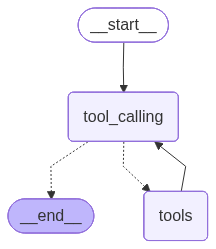

In [17]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

def tool_calling(state:State):
    return {"messages":[tooled_llm.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("tool_calling",tool_calling)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START, "tool_calling")
builder.add_conditional_edges("tool_calling",tools_condition)
builder.add_edge("tools","tool_calling")

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [18]:
messages=graph.invoke({"messages":HumanMessage(content="Provide the recent news on petrol in India, also give the result of adding 7 and 10 then mutliplying it by 10.")})
for m in messages["messages"]:
    m.pretty_print()

APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `openai/gpt-oss-20b` in organization `org_01jsyn46z9eqdrdg1267qtt2r1` service tier `on_demand` on tokens per minute (TPM): Limit 8000, Requested 9498, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

In [ ]:
messages=graph.invoke({"messages":HumanMessage(content="What is React in Javascript?")})
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is React in Javascript?
================================== Ai Message ==================================

**React** (often called **React.js** or **ReactJS**) is an open‑source JavaScript library for building user interfaces, especially single‑page applications where you want a fast, dynamic, and responsive UI. It was created by Facebook (now Meta) and released publicly in 2013.

### Core concepts

| Concept | What it is | Why it matters |
|---------|------------|----------------|
| **Components** | Reusable, self‑contained UI building blocks that can be composed to create complex interfaces. | Keeps code modular, easier to test, maintain, and reuse. |
| **JSX** | A syntax extension that lets you write XML/HTML‑like markup directly in JavaScript. | Makes component templates readable and declarative. |
| **Virtual DOM** | An in‑memory representation of the real DOM. | React updates this virtual tree, 

In [ ]:
messages=graph.invoke({"messages":HumanMessage(content="What is the current version of React in Javascript?")})
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is the current version of React in Javascript?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_367145f9-8fd7-46f8-a05e-66de4e230c1d)
 Call ID: fc_367145f9-8fd7-46f8-a05e-66de4e230c1d
  Args:
    query: latest version of React 2026
    search_depth: basic
================================= Tool Message =================================
Name: tavily_search

{"query": "latest version of React 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://medium.com/@sindhujad6/react-versions-explained-why-lts-matters-and-which-versions-are-safe-c53a984e62a3", "title": "React Versions Explained: Why LTS Matters and Which ... - Medium", "content": "React 18 LTS is currently the recommended, safe, and stable version for production applications as of January 2026. Older versions like React 14", "score": 0.7950386

In [19]:
messages = graph.invoke({"messages":HumanMessage(content="What is 12+8?")})
for msg in messages["messages"]:
    msg.pretty_print()

================================ Human Message =================================

What is 12+8?
================================== Ai Message ==================================
Tool Calls:
  add (fc_6788d953-9b04-4293-baa3-60999ea0457f)
 Call ID: fc_6788d953-9b04-4293-baa3-60999ea0457f
  Args:
    a: 12
    b: 8
================================= Tool Message =================================
Name: add

20
================================== Ai Message ==================================

12 + 8 = 20


In [21]:
messages=[HumanMessage(content="Divide that by 5")]
messages = graph.invoke({"messages":messages})
for msg in messages["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Divide that by 5
================================== Ai Message ==================================

I’m not sure what number you’d like me to divide by 5. Could you let me know which value you’re referring to?


In [22]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

def tool_calling(state:State):
    return {"messages":[tooled_llm.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("tool_calling",tool_calling)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START, "tool_calling")
builder.add_conditional_edges("tool_calling",tools_condition)
builder.add_edge("tools","tool_calling")

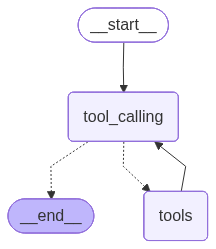

In [23]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
graph_memory = builder.compile(checkpointer=memory)

display(Image(graph_memory.get_graph().draw_mermaid_png()))

In [24]:
config={"configurable":{"thread_id":"1"}}

messages = [HumanMessage(content="Add 12 and 13.")]
messages = graph_memory.invoke({"messages":messages},config=config)
for msg in messages["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Add 12 and 13.
================================== Ai Message ==================================
Tool Calls:
  add (fc_ddf7c6d2-867c-48dd-9faa-3b58f92e0bff)
 Call ID: fc_ddf7c6d2-867c-48dd-9faa-3b58f92e0bff
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

25


In [25]:
messages = [HumanMessage(content="Add that number to 25.")]
messages = graph_memory.invoke({"messages":messages},config=config)
for msg in messages["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Add 12 and 13.
================================== Ai Message ==================================
Tool Calls:
  add (fc_ddf7c6d2-867c-48dd-9faa-3b58f92e0bff)
 Call ID: fc_ddf7c6d2-867c-48dd-9faa-3b58f92e0bff
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

25
================================ Human Message =================================

Add that number to 25.
================================== Ai Message ==================================
Tool Calls:
  add (fc_eaaa6ad2-a714-4d62-bf69-5115ef605d28)
 Call ID: fc_eaaa6ad2-a714-4d62-bf69-5115ef605d28
  Args:
    a: 25
    b: 25
================================= Tool Message =================================
Name: add

50
================================== Ai Message ==================================

50


In [26]:
messages = [HumanMessage(content="Divide that number by 2.")]
messages = graph_memory.invoke({"messages":messages},config=config)
for msg in messages["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Add 12 and 13.
================================== Ai Message ==================================
Tool Calls:
  add (fc_ddf7c6d2-867c-48dd-9faa-3b58f92e0bff)
 Call ID: fc_ddf7c6d2-867c-48dd-9faa-3b58f92e0bff
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

25
================================ Human Message =================================

Add that number to 25.
================================== Ai Message ==================================
Tool Calls:
  add (fc_eaaa6ad2-a714-4d62-bf69-5115ef605d28)
 Call ID: fc_eaaa6ad2-a714-4d62-bf69-5115ef605d28
  Args:
    a: 25
    b: 25
================================= Tool Message =================================
Name: add

50
================================== Ai Message ==================================

50
